# Eligiendo modelos con incertidumbre

> All models are wrong, but some are useful.

George Box

> If you torture the data long enough, it will confess.

Ronald Coase

Necesitamos ganar la competencia. Para lograr esto, necesitamos "construir" el mejor modelo posible. Lo que nos platea dos preguntas clave:
* ¿qué significa construir un modelo?
* Y, en segundo lugar, si tenemos dos modelos, ¿cómo determinamos cuál es el mejor?

Empecemos realizando una comparación entre el modelo por defecto  de **árboles de decisión** (no controla el crecimiento) y uno levemente parametrizado.

Levantemos el entorno e instalemos los paquetes que nos probablemente no dispongamos. Se usarán a lo largo de la clase.

In [1]:
%pip install optuna plotly


   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [Mako]
   -------- ------------------------------- 1/5 [Mako]
   -------- ------------------------------- 1/5 [Mako]
   ------------------------ --------------- 3/5 [alembic]
   ------------------------ --------------- 3/5 [alembic]
   ------------------------ --------------- 3/5 [alembic]
   ------------------------ --------------- 3/5 [alembic]
   ------------------------ --------------- 3/5 [alembic]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   -------------------------------- ------- 4/5 [optuna]
   ------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree,  _tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit

from joblib import Parallel, delayed

from time import time

import optuna
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history

ModuleNotFoundError: No module named 'seaborn'

Notará a continuación que trabajaremos como mes de entrenamiento **Marzo** y reservaremos **Mayo** solo para pruebas

In [ ]:
from pathlib import Path

# Ruta local del proyecto (no depende del directorio desde el que se inicio Jupyter).
project_path = Path(r'C:\Users\tomas\OneDrive\Documents\Maestria\DMEyF\dmeyf2026')
dataset_path = project_path / 'data'
dataset_file = 'competencia_01.csv'

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

mes_train = 202103
mes_test = 202105

# agregue su semilla
semilla = 17

data = pd.read_csv(dataset_path / dataset_file)

In [ ]:
X = data[data['foto_mes'] == mes_train]
y = X['clase_ternaria']
X = X.drop(columns=['clase_ternaria'])

Y necesitamos una función que nos ayude a calcular la ganancia.

El parámetro `prop`, esta para corregir la ganancia cuando no estemos trabajando con una población entera. Si estamos utilizando, por ejemplo una muestra del 70%, para normalizar la ganancia, ponermos el parámetro `prop=0.7`



In [ ]:
def ganancia(model, X, y, prop=1, threshold=0.025):

  class_index = np.where(model.classes_ == "BAJA+2")[0][0]
  y_hat = model.predict_proba(X)

  @np.vectorize
  def ganancia_row(predicted, actual, threshold=0.025):
    return  (predicted >= threshold) * (ganancia_acierto if actual == "BAJA+2" else -costo_estimulo)

  return ganancia_row(y_hat[:,class_index], y).sum() / prop


Mira a continuación el siguiente código.

* ¿Cuál cree que es el mejor modelo?
* ¿Cuáles son los problemas que ve?

In [ ]:
model_base = DecisionTreeClassifier()
model_ale = DecisionTreeClassifier(criterion='gini',
                               min_samples_split=80,
                               max_depth=5)

model_base.fit(X,y)
model_ale.fit(X,y)

print(f"Ganancia de modelo Base: {ganancia(model_base, X, y):,.0f}")
print(f"Ganancia de modelo Ale:  {ganancia(model_ale, X, y):,.0f}")

* ¿Cómo se pueden solucionar?

Dado que lo que hicimos no pinta nada bien, pasemos a una de las herramientas que separa la ciencia de datos de la estadística tradicional

* ¿Por qué separamos en train/test?
* ¿Cómo funciona la estadística tradicional?
* ¿Son números aleatorios los que nos dan las computadoras?
* ¿Por qué usamos semillas?
* ¿Qué es una partición estratificada?
* ¿Es realmente necesario en nuestro caso una partición estratificada?



Veamos alguna de las formas de separar los conjuntos de datos para medir su calidad:

* **Train-Test Split**: Divide el conjunto de datos en dos partes: un conjunto de entrenamiento y otro de prueba. El conjunto de entrenamiento se utiliza para ajustar el modelo, y el conjunto de prueba para evaluar su rendimiento.

* **K-Fold Cross Validation**: Divide los datos en k subconjuntos o folds. El modelo se entrena k veces, cada vez utilizando k-1 subconjuntos como entrenamiento y el subconjunto restante como prueba. Esto se repite hasta que cada subconjunto se haya utilizado como conjunto de prueba una vez.

* **Shuffle Split** (aka Montecarlo Cross Validation): Genera múltiples particiones aleatorias de los datos en conjuntos de entrenamiento y prueba. A diferencia de K-Fold, no garantiza que todos los puntos de datos sean utilizados en alguna iteración.

En la cátedra preferimos usar está última, pero el alumno es libre de usar la que considera conveniente.

Armemos ahora nuevamente los modelos anteriores, pero utilizando estas particiones y midiendo ya no en **train**, sino en los múltiples conjunto de **test**

In [ ]:
sss = StratifiedShuffleSplit(n_splits=20,
                             test_size=0.3,
                             random_state=semilla)

# Función que paraleliza la construcción de árboles de decisión
def train_and_evaluate(train_index, test_index, params, X, y):
  m = DecisionTreeClassifier(**params)
  m.fit(X.iloc[train_index],y.iloc[train_index])
  # Note que con el parámetro prop se corrige la distorsión por sampleo de la
  # ganancia
  ganancia_value = ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)
  return m, ganancia_value

modelo_base_param = {"random_state":semilla}

modelo_ale_param = {"criterion": 'gini',
                     "random_state":semilla,
                     "min_samples_split":80,
                     "max_depth":5,
}

results_base = Parallel(n_jobs=-1)(
    delayed(train_and_evaluate)(train_index, test_index, modelo_base_param, X, y)
    for train_index, test_index in sss.split(X, y)
)

results_ale = Parallel(n_jobs=-1)(
    delayed(train_and_evaluate)(train_index, test_index, modelo_ale_param, X, y)
    for train_index, test_index in sss.split(X, y)
)


Estamos haciendo por cada juego de parámetros 20 modelos. Esto no suele ser lo habitual. Con 5 se puede conseguir resultados aceptables para una comparación inicial.

Vamos a ver que tan bien le fue a los modelos en los conjuntos de **test**:

In [ ]:
ganancias_modelos_base = [result[1] for result in results_base]
ganancias_modelos_ale = [result[1] for result in results_ale]

df_pred = pd.DataFrame({'Ganancia': [result[1] for result in results_base], 'Modelo': 'Base'})
df_pred2 = pd.DataFrame({'Ganancia': [result[1] for result in results_ale], 'Modelo': 'Ale'})
df_combined = pd.concat([df_pred, df_pred2])
df_combined_pivot = df_combined.pivot(columns='Modelo', values='Ganancia')
display(df_combined_pivot)

In [ ]:
g = sns.FacetGrid(df_combined, row="Modelo", aspect=2)
g.map(sns.histplot, "Ganancia", kde=True)
plt.show()

* ¿Qué tan distintos son de los primero valores calculados con el modelo completo?
* ¿Con cuál se queda?
* ¿Por qué se produce semejante dispersión?
* ¿Cuál considera que es el "valor real"?

Podemos mirar la media

In [ ]:
mean_base = df_combined[df_combined['Modelo'] == 'Base']['Ganancia'].mean()
mean_ale = df_combined[df_combined['Modelo'] == 'Ale']['Ganancia'].mean()

print(f"Ganancia media del modelo base:\t{mean_base/0.3:,.0f}")
print(f"Ganancia media del modelo ale:\t{mean_ale/0.3:,.0f}")

* Si no le gusta la media, ¿cómo más puede elegir entre dos modelos?

Muy interesante, pero lo importante es que sucedería en el **futuro**. Por este motivo nos guardamos el mes de **Mayo**.

In [ ]:
X_futuro = data[data['foto_mes'] == mes_test]
y_futuro = X_futuro['clase_ternaria']
X_futuro = X_futuro.drop(columns=['clase_ternaria'])

Sobre el mes de Mayo, **debemos usar el modelo que se entreno sobre todos los datos**

In [ ]:
ganancia_mayo_base = ganancia(model_base, X_futuro, y_futuro)
ganancia_mayo_ale = ganancia(model_ale, X_futuro, y_futuro)

print(f"Ganancia de modelo Base en Abril:\t{ganancia_mayo_base:,.0f}")
print(f"Ganancia de modelo Ale en Abril:\t{ganancia_mayo_ale:,.0f}")


* ¿Cuál es mejor?
* ¿Por qué cree que el mejor es el mejor?
* ¿Hubiera elegido sabiamente únicamente con los datos de **Febrero**?

El mundo es un lugar **cruel** para los data scientists. El escenario anterior tampoco es el presente para los alumnos. Ya que la primera competencia sigue el modelo **kaggle** que divide el dataset en una parte **pública** y otra **privada**. Simulemos los efectos que produce en la decisión del mejor modelo en los leaderboards, simulando varios a la vez.


In [ ]:
# podemos tomar más muestras, dado que solo vamos a scorear y eso es más rápido
sss_futuro = StratifiedShuffleSplit(n_splits=50,
                             test_size=0.3,
                             random_state=semilla)

ganancias_futuro_privada_ale = []
ganancias_futuro_privada_base = []
ganancias_futuro_publica_ale = []
ganancias_futuro_publica_base = []

for train_index, test_index in sss_futuro.split(X_futuro, y_futuro):
  ganancias_futuro_privada_ale.append(ganancia(model_ale, X_futuro.iloc[train_index], y_futuro.iloc[train_index], prop=0.7))
  ganancias_futuro_privada_base.append(ganancia(model_base, X_futuro.iloc[train_index], y_futuro.iloc[train_index], prop=0.7))
  ganancias_futuro_publica_ale.append(ganancia(model_ale, X_futuro.iloc[test_index], y_futuro.iloc[test_index], prop=0.3))
  ganancias_futuro_publica_base.append(ganancia(model_base, X_futuro.iloc[test_index], y_futuro.iloc[test_index], prop=0.3))


In [ ]:
df_pred_1_ale = pd.DataFrame({'Ganancia': ganancias_futuro_privada_ale, 'Modelo': 'ale', 'Grupo': 'Privado'})
df_pred_2_ale = pd.DataFrame({'Ganancia': ganancias_futuro_publica_ale, 'Modelo': 'ale', 'Grupo': 'Publico'})
df_pred_1_base = pd.DataFrame({'Ganancia': ganancias_futuro_privada_base, 'Modelo': 'Base', 'Grupo': 'Privado'})
df_pred_2_base = pd.DataFrame({'Ganancia': ganancias_futuro_publica_base, 'Modelo': 'Base', 'Grupo': 'Publico'})

df_combined = pd.concat([df_pred_1_base, df_pred_2_base, df_pred_1_ale, df_pred_2_ale ])

g = sns.FacetGrid(df_combined, col="Grupo", row="Modelo", aspect=2)
g.map(sns.histplot, "Ganancia", kde=True)
plt.show()


In [ ]:
mean_base_privado = df_combined[(df_combined['Modelo'] == 'Base') & (df_combined['Grupo'] == 'Privado')]['Ganancia'].mean()
mean_base_publico = df_combined[(df_combined['Modelo'] == 'Base') & (df_combined['Grupo'] == 'Publico')]['Ganancia'].mean()
mean_ale_privado = df_combined[(df_combined['Modelo'] == 'ale') & (df_combined['Grupo'] == 'Privado')]['Ganancia'].mean()
mean_ale_publico = df_combined[(df_combined['Modelo'] == 'ale') & (df_combined['Grupo'] == 'Publico')]['Ganancia'].mean()

print(f"Ganancia media del modelo base en privado: {mean_base_privado}")
print(f"Ganancia media del modelo base en publico: {mean_base_publico}")
print(f"Ganancia media del modelo ale en privado: {mean_ale_privado}")
print(f"Ganancia media del modelo ale en publico: {mean_ale_publico}")


* ¿Que significan estos resultados?

Dos cosas.

* El modelo ale, es un caso de **vagancia**. Cambiar 2 parámetros y esperar un cambio radical no es lo más inteligente que se puede hacer. Realmente hay que hacer un esfuerzo para separar las distribuciones.
* Elegir un modelo no es una tarea simple que se pueda hacer con una **certeza** absoluta.

Para encontrar buenos modelos una forma adecuada es la búsqueda de hiperparámetros. Podemos contar con las siguientes técnicas de búsqueda de hiperparámetros:

* **Grid Search**: Explora exhaustivamente todas las combinaciones posibles de hiperparámetros dentro de un conjunto predefinido de valores. Aunque es exhaustivo.

* **Random Search**: En lugar de probar todas las combinaciones posibles, selecciona un número aleatorio de combinaciones de hiperparámetros dentro de un rango predefinido.

* **Bayesian Optimization**: Este método construye un modelo probabilístico del rendimiento de los hiperparámetros y utiliza ese modelo para seleccionar los valores de hiperparámetros más prometedores.

* **Tree-structured Parzen Estimator (TPE)**: Una variante de la optimización bayesiana que utiliza estimadores de densidad basados en árboles (Parzen estimators) para modelar la probabilidad de los hiperparámetros óptimos. Es eficiente en la exploración de espacios de hiperparámetros complejos y se adapta bien a configuraciones con interdependencias entre los parámetros.

* **Genetic Algorithms**: Emplea principios de la evolución natural, como selección, cruce y mutación, para encontrar combinaciones óptimas de hiperparámetros. Es útil en espacios de búsqueda muy complejos, aunque puede ser computacionalmente costoso.

Todos son buenas opciones para la búsqueda de ... nah mentira, **grid search** apesta, si no me cree calcule el tiempo necesario para barrer el dominio de búsqueda.

Para la búsquedas de parámetros usaremos **Optuna**. **Optuna** es una librería poderosa y flexible, diseñada para realizar búsquedas eficientes y automatizadas.

* Utiliza casi todos los álgoritmos mencionados y más.

* Permite definir espacios de búsqueda complejos, incluyendo hiperparámetros categóricos, continuos, discretos y con dependencias condicionales.

* Ofrece un mecanismo de pruning o poda, que permite detener evaluaciones de configuraciones de hiperparámetros que no muestran promesas tempranas.

* Facilidad de Uso y Configuración.

* Proporciona herramientas de visualización integradas para analizar el progreso de la optimización, visualizar la importancia de los hiperparámetros y explorar las configuraciones probadas.

Buscaremos un mejor modelo de manera inteligente:

In [20]:

sss_opt = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=semilla)

def objective(trial, X, y, sss):
  # Limitaremos la busqueda a solo 3 hiperparámetros, pero puede poner los que quiera
  # criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
  max_depth = trial.suggest_int('max_depth', 2, 20)
  min_samples_split = trial.suggest_int('min_samples_split', 2, 200)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
  # max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 2, 20)

  def train_and_evaluate(train_index, test_index, X, y):
    m = DecisionTreeClassifier(
        # criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        # max_leaf_nodes=max_leaf_nodes,
        random_state=semilla,
    )
    m.fit(X.iloc[train_index],y.iloc[train_index])
    ganancia_value = ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)
    return ganancia_value

  results = Parallel(n_jobs=-1)(
      delayed(train_and_evaluate)(train_index, test_index, X, y)
      for train_index, test_index in sss.split(X, y)
  )

  return np.mean(results)

# La base SQLite se guarda en la carpeta data local.
# Se reconstruye como Path para que esta celda sea independiente del estado previo del kernel.
dataset_path = Path(r'C:\Users\tomas\OneDrive\Documents\Maestria\DMEyF\dmeyf2026') / 'data'
dataset_path.mkdir(parents=True, exist_ok=True)
db_path = (dataset_path / 'optimization_tree.db').resolve()
storage_name = f"sqlite:///{db_path.as_posix()}"
# Nuevo nombre = experimento limpio, independiente de los 200 trials anteriores.
study_name = "exp_102_decision-tree-opt"

study = optuna.create_study(
    direction="maximize",
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
)

NameError: name 'Path' is not defined

Entre la muchas ventajas que tiene **Optuna** es que va almacenando las exploraciones en una base de datos, lo que nos permite continuar la búsqueda si esta se interrumpe.

In [ ]:
# Se buscan 100 trials EN TOTAL. Si se reejecuta la celda, sólo completa los faltantes.
objetivo_trials = 100
trials_faltantes = max(0, objetivo_trials - len(study.trials))
print(f'Trials existentes: {len(study.trials)}; trials a ejecutar: {trials_faltantes}')
if trials_faltantes > 0:
    study.optimize(
        lambda trial: objective(trial, X, y, sss_opt),
        n_trials=trials_faltantes,
        show_progress_bar=True,
    )

A continuación veremos como fue el proceso de búsqueda a través de las visualizaciones que cuenta la herramienta (los gráficos son bastante autoexplicativos)

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
plot_slice(study)

In [ ]:
plot_contour(study)

In [ ]:
plot_contour(study, params=["max_depth", "min_samples_leaf"])

* Observe los valles y las montañas en las distintas combinaciones de parámetros. ¿Seguiría explorando?
* Si una montaña esta cerca del máximo del intervalo que exploración de un hiperparámetro. ¿Qué recomienda hacer?
* Existe alguna relación intrinseca entre le `min_sample_leaf` y `min_sample_split`? Puede mejorar esta búsqueda conectando estos parámetros?

Pasemos a analizar como le fue al mejor modelo en **Mayo**

In [ ]:
# Obtener el mejor modelo
best_trial = study.best_trial
best_model_params = best_trial.params
print("Mejor modelo:", best_model_params)

model_best = DecisionTreeClassifier(**best_model_params, random_state=semilla)
model_best.fit(X, y)

print(f"Ganancia del mejor modelo: {ganancia(model_best, X_futuro, y_futuro)}")

Es mejor que los anteriores! y solo por una hora de procesamiento!!!

¿qué más podemos pedir por tan poco?

Veamos comparados con los anteriores que tanto mejor es...


In [ ]:
ganancias_futuro_top0_publica = []
ganancias_futuro_top0_privado = []
for train_index, test_index in sss_futuro.split(X_futuro, y_futuro):
  ganancias_futuro_top0_publica.append(ganancia(model_best, X_futuro.iloc[test_index], y_futuro.iloc[test_index], prop=0.3))
  ganancias_futuro_top0_privado.append(ganancia(model_best, X_futuro.iloc[train_index], y_futuro.iloc[train_index], prop=0.7))

df_pred_top0_privado = pd.DataFrame({'Ganancia': ganancias_futuro_top0_privado, 'Modelo': 'top0', 'Grupo': 'Privado'})
df_pred_top0_publica = pd.DataFrame({'Ganancia': ganancias_futuro_top0_publica, 'Modelo': 'top0', 'Grupo': 'Publico'})

df_combined = pd.concat([df_pred_1_base,
                         df_pred_2_base,
                         df_pred_1_ale,
                         df_pred_2_ale,
                         df_pred_top0_privado,
                         df_pred_top0_publica])

g = sns.FacetGrid(df_combined, col="Grupo", row="Modelo", aspect=2)
g.map(sns.histplot, "Ganancia", kde=True)
plt.show()

Bueno, no parece mucho mejor. Es tan solo mejor. Vamos moviendo de a poco la vara.

* ¿Qué se puede hacer para mejorarlo? Debate con la clase abierta


## Tarea:

* Ejecute todo de nuevo para su semilla y los hiperparámetros que considere.
* Ya tiene la búsqueda de Optuna. Duda existencial: Dado que no hay tanta distancia entre el primer modelo y los subsiguientes en optuna y que a su vez hicimos apenas 5 muestreos, no será posible que el mejor modelo en SSS no sea el mejor en el privado de **Mayo**?
    * Quédese con los top 5 de optuna. Use más muestras para cada modelo (20 o más)
    * Calcule la ganancia y su distribución en los conjuntos de validación
    * Cómo son las medias? ayudan a elegir el mejor modelo en el privado? con que confianza?
    * Sólo mirando la distribución del muestreo de validación, tiene herramientas para elegir el mejor modelo en el privado?
    * Puede pasar que comparando 2 modelos uno le gane al otro en el público, pero no así en el privado? En que porcentaje pasa?
         
Colaboración:
* Recuerde compartir con tus compañeros los nuevos scripts que hayas generado y las configuraciones que hayas probado por Zulip

## Resolución: estabilidad de los top 5 de Optuna

Se toman los cinco mejores trials completos y se los reevalúa sobre **las mismas 30 particiones estratificadas** de marzo. Al usar muestras pareadas, la comparación separa mejor el efecto del modelo del efecto de una muestra particularmente fácil o difícil.


In [90]:
# Top 5 de Optuna (se excluyen trials fallidos o incompletos)
trials_ok = [t for t in study.trials
             if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None]
if len(trials_ok) < 5:
    raise ValueError(f'Se necesitan 5 trials completos; actualmente hay {len(trials_ok)}.')
# Se evitan configuraciones exactamente repetidas entre los cinco candidatos.
top5_trials, configuraciones_vistas = [], set()
for trial in sorted(trials_ok, key=lambda t: t.value, reverse=True):
    configuracion = tuple(sorted(trial.params.items()))
    if configuracion not in configuraciones_vistas:
        configuraciones_vistas.add(configuracion)
        top5_trials.append(trial)
    if len(top5_trials) == 5:
        break
top5_info = pd.DataFrame([{'Modelo': f'Trial {t.number}',
                           'Media original (5 SSS)': t.value, **t.params}
                          for t in top5_trials])
display(top5_info.style.format({'Media original (5 SSS)': '{:,.0f}'}))

,Modelo,Media original (5 SSS),max_depth,min_samples_split,min_samples_leaf
0,Trial 95,"302,665,000",9,181,3
1,Trial 62,"300,208,333",9,168,3
2,Trial 36,"297,018,333",9,183,4
3,Trial 41,"297,018,333",9,177,4
4,Trial 52,"297,018,333",9,181,4


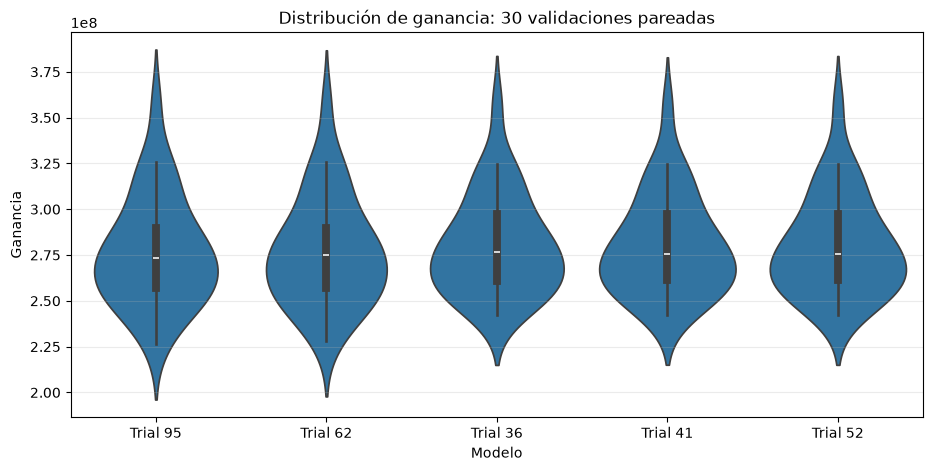

In [91]:
# Reevaluación: 30 validaciones pareadas sobre marzo
sss_tarea = StratifiedShuffleSplit(n_splits=30, test_size=0.30,
                                    random_state=semilla + 301)
splits_tarea = list(sss_tarea.split(X, y))

def evaluar_top(trial, muestra, idx_train, idx_valid):
    params = {**trial.params, 'random_state': semilla}
    modelo = DecisionTreeClassifier(**params)
    modelo.fit(X.iloc[idx_train], y.iloc[idx_train])
    valor = ganancia(modelo, X.iloc[idx_valid], y.iloc[idx_valid], prop=0.30)
    return {'Modelo': f'Trial {trial.number}', 'Trial': trial.number,
            'Muestra': muestra, 'Ganancia': valor}

filas_validacion = Parallel(n_jobs=-1)(
    delayed(evaluar_top)(trial, muestra, idx_train, idx_valid)
    for trial in top5_trials
    for muestra, (idx_train, idx_valid) in enumerate(splits_tarea)
)
df_validacion_top5 = pd.DataFrame(filas_validacion)

plt.figure(figsize=(11, 5))
sns.violinplot(data=df_validacion_top5, x='Modelo', y='Ganancia', inner='box')
plt.title('Distribución de ganancia: 30 validaciones pareadas')
plt.grid(axis='y', alpha=.25)
plt.show()

In [92]:
# Medias descriptivas y tests de hipótesis pareados
from scipy.stats import wilcoxon

resumen_val = (df_validacion_top5.groupby(['Modelo', 'Trial'])['Ganancia']
               .agg(Media='mean', Desvio='std', N='count', Mediana='median')
               .reset_index())
resumen_val = resumen_val.sort_values('Media', ascending=False).reset_index(drop=True)
display(resumen_val.style.format({c: '{:,.0f}' for c in
        ['Media', 'Desvio', 'Mediana']}))

# H0: la mediana de las diferencias pareadas de ganancia es cero.
# H1: la mediana de las diferencias es distinta de cero (Wilcoxon bilateral).
# Se prueban los 10 pares y se corrigen los p-valores con el método de Holm.
mejor_val = resumen_val.loc[0, 'Modelo']
piv_val = df_validacion_top5.pivot(index='Muestra', columns='Modelo', values='Ganancia')
comparaciones = []
modelos_val = list(piv_val.columns)
for i, modelo_a in enumerate(modelos_val):
    for modelo_b in modelos_val[i + 1:]:
        d = piv_val[modelo_a] - piv_val[modelo_b]
        if np.allclose(d, 0):
            estadistico, p_crudo = 0.0, 1.0
        else:
            estadistico, p_crudo = wilcoxon(d, alternative='two-sided')
        comparaciones.append({
            'Modelo A': modelo_a, 'Modelo B': modelo_b,
            'Diferencia media A-B': d.mean(),
            '% muestras donde A gana': 100*(d > 0).mean(),
            'Estadístico W': estadistico, 'p crudo': p_crudo})
df_comparaciones = pd.DataFrame(comparaciones)

# Ajuste de Holm: controla el error familiar al comparar varios pares.
orden = np.argsort(df_comparaciones['p crudo'].to_numpy())
m = len(orden)
p_ordenados = df_comparaciones.loc[orden, 'p crudo'].to_numpy()
p_holm_ordenados = np.maximum.accumulate((m - np.arange(m)) * p_ordenados)
p_holm = np.empty(m)
p_holm[orden] = np.minimum(1, p_holm_ordenados)
df_comparaciones['p ajustado Holm'] = p_holm
df_comparaciones['Diferencia significativa (5%)'] = df_comparaciones['p ajustado Holm'] < 0.05
df_comparaciones = df_comparaciones.sort_values('p ajustado Holm').reset_index(drop=True)
display(df_comparaciones.style.format({
    'Diferencia media A-B': '{:,.0f}', '% muestras donde A gana': '{:.1f}%',
    'Estadístico W': '{:.1f}', 'p crudo': '{:.4f}', 'p ajustado Holm': '{:.4f}'}))

,Modelo,Trial,Media,Desvio,N,Mediana
0,Trial 36,36,"280,121,111","27,086,485",30,"276,879,167"
1,Trial 52,52,"280,075,278","27,031,335",30,"275,733,333"
2,Trial 41,41,"280,053,889","26,977,303",30,"275,733,333"
3,Trial 62,62,"276,964,722","29,658,281",30,"275,045,833"
4,Trial 95,95,"276,769,167","29,722,207",30,"273,258,333"


,Modelo A,Modelo B,Diferencia media A-B,% muestras donde A gana,Estadístico W,p crudo,p ajustado Holm,Diferencia significativa (5%)
0,Trial 36,Trial 62,"3,156,389",60.0%,147.0,0.0786,0.7863,False
1,Trial 36,Trial 95,"3,351,944",63.3%,154.5,0.1086,0.8988,False
2,Trial 41,Trial 95,"3,284,722",60.0%,158.5,0.1280,0.8988,False
3,Trial 41,Trial 62,"3,089,167",63.3%,155.5,0.1132,0.8988,False
4,Trial 52,Trial 62,"3,110,556",63.3%,152.5,0.0999,0.8988,False
5,Trial 52,Trial 95,"3,306,111",63.3%,157.5,0.1229,0.8988,False
6,Trial 36,Trial 41,"67,222",13.3%,13.5,0.9325,1.0000,False
7,Trial 36,Trial 52,"45,833",3.3%,3.0,1.0000,1.0000,False
8,Trial 41,Trial 52,"-21,389",3.3%,4.0,0.7150,1.0000,False
9,Trial 62,Trial 95,"195,556",30.0%,50.5,0.5892,1.0000,False


### Público versus privado de mayo

Cada top 5 se entrena con todo marzo. Luego se simulan 100 divisiones de mayo: 30% público y 70% privado. Se conserva el mismo split para todos los modelos y se normaliza la ganancia por el tamaño de cada grupo.


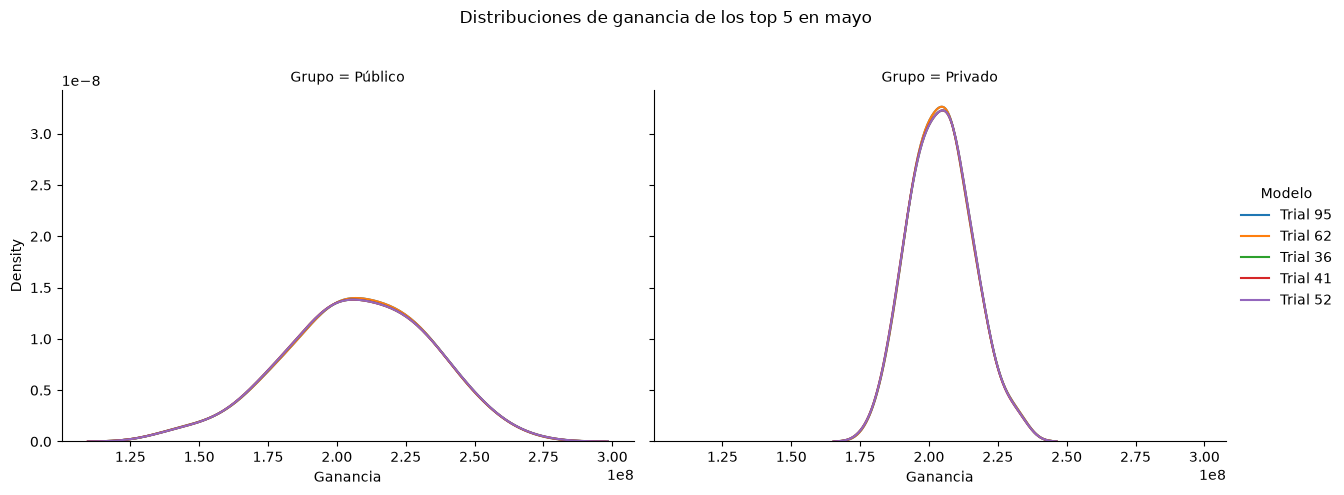

In [93]:
# Entrenamiento final y aporte de ganancia de cada fila de mayo
modelos_top5, aportes_mayo = {}, {}
for trial in top5_trials:
    nombre = f'Trial {trial.number}'
    modelo = DecisionTreeClassifier(**trial.params, random_state=semilla)
    modelo.fit(X, y)
    modelos_top5[nombre] = modelo
    clase = np.where(modelo.classes_ == 'BAJA+2')[0][0]
    estimula = modelo.predict_proba(X_futuro)[:, clase] >= 0.025
    aportes_mayo[nombre] = np.where(estimula,
        np.where(np.asarray(y_futuro) == 'BAJA+2', ganancia_acierto, -costo_estimulo), 0)

sss_mayo_tarea = StratifiedShuffleSplit(n_splits=100, test_size=0.30,
                                         random_state=semilla + 302)
filas_mayo = []
for muestra, (idx_priv, idx_pub) in enumerate(sss_mayo_tarea.split(X_futuro, y_futuro)):
    for nombre, aportes in aportes_mayo.items():
        filas_mayo += [
            {'Modelo': nombre, 'Muestra': muestra, 'Grupo': 'Público',
             'Ganancia': aportes[idx_pub].sum()/0.30},
            {'Modelo': nombre, 'Muestra': muestra, 'Grupo': 'Privado',
             'Ganancia': aportes[idx_priv].sum()/0.70}]
df_mayo_top5 = pd.DataFrame(filas_mayo)

g = sns.FacetGrid(df_mayo_top5, col='Grupo', hue='Modelo', height=5, aspect=1.25)
g.map(sns.kdeplot, 'Ganancia').add_legend()
g.fig.subplots_adjust(top=.82)
g.fig.suptitle('Distribuciones de ganancia de los top 5 en mayo')
plt.show()

In [94]:
# Medias de mayo e inversión del ganador entre público y privado
resumen_mayo = (df_mayo_top5.groupby(['Grupo', 'Modelo'])['Ganancia']
                .agg(Media='mean', Desvio='std', Mediana='median').reset_index()
                .sort_values(['Grupo', 'Media'], ascending=[True, False]))
display(resumen_mayo.style.format({c: '{:,.0f}' for c in ['Media','Desvio','Mediana']}))

piv_mayo = df_mayo_top5.pivot(index='Muestra', columns=['Grupo','Modelo'], values='Ganancia')
nombres = list(modelos_top5)
inversiones = []
for i, a in enumerate(nombres):
    for b in nombres[i+1:]:
        dpub = piv_mayo[('Público', a)] - piv_mayo[('Público', b)]
        dpriv = piv_mayo[('Privado', a)] - piv_mayo[('Privado', b)]
        inversiones.append({'Modelo A': a, 'Modelo B': b,
          '% ganador distinto': 100*((dpub*dpriv) < 0).mean(),
          '% A gana público y pierde privado': 100*((dpub > 0)&(dpriv < 0)).mean(),
          '% B gana público y pierde privado': 100*((dpub < 0)&(dpriv > 0)).mean()})
df_inversiones = pd.DataFrame(inversiones).sort_values('% ganador distinto', ascending=False)
display(df_inversiones.style.format({c: '{:.1f}%' for c in df_inversiones if c.startswith('%')}))

,Grupo,Modelo,Media,Desvio,Mediana
3,Privado,Trial 62,"204,385,893","11,102,513","204,521,429"
4,Privado,Trial 95,"204,385,893","11,102,513","204,521,429"
0,Privado,Trial 36,"204,354,464","11,138,169","204,619,643"
2,Privado,Trial 52,"204,354,464","11,138,169","204,619,643"
1,Privado,Trial 41,"204,304,571","11,136,218","204,560,714"
8,Público,Trial 62,"207,482,917","25,905,864","207,166,667"
9,Público,Trial 95,"207,482,917","25,905,864","207,166,667"
5,Público,Trial 36,"207,464,583","25,989,061","206,845,833"
7,Público,Trial 52,"207,464,583","25,989,061","206,845,833"
6,Público,Trial 41,"207,397,667","25,984,508","206,800,000"


,Modelo A,Modelo B,% ganador distinto,% A gana público y pierde privado,% B gana público y pierde privado
1,Trial 95,Trial 36,89.0%,44.0%,45.0%
3,Trial 95,Trial 52,89.0%,44.0%,45.0%
6,Trial 62,Trial 52,89.0%,44.0%,45.0%
4,Trial 62,Trial 36,89.0%,44.0%,45.0%
5,Trial 62,Trial 41,74.0%,36.0%,38.0%
2,Trial 95,Trial 41,74.0%,36.0%,38.0%
0,Trial 95,Trial 62,0.0%,0.0%,0.0%
7,Trial 36,Trial 41,0.0%,0.0%,0.0%
8,Trial 36,Trial 52,0.0%,0.0%,0.0%
9,Trial 41,Trial 52,0.0%,0.0%,0.0%


In [95]:
# Síntesis numérica para contestar la consigna
mejor_privado = (resumen_mayo.query("Grupo == 'Privado'")
                  .sort_values('Media', ascending=False).iloc[0].Modelo)
pares_significativos = int(df_comparaciones['Diferencia significativa (5%)'].sum())
print(f'Mejor por media de validación: {mejor_val}')
print(f'Mejor por media en el privado de mayo: {mejor_privado}')
print(f'¿Coinciden?: {mejor_val == mejor_privado}')
print(f'Pares con diferencia significativa (Wilcoxon + Holm, alfa=5%): '
      f'{pares_significativos} de {len(df_comparaciones)}')
print(f'Inversión promedio entre pares: {df_inversiones["% ganador distinto"].mean():.1f}%')
print(f'Inversión máxima entre pares: {df_inversiones["% ganador distinto"].max():.1f}%')

Mejor por media de validación: Trial 36
Mejor por media en el privado de mayo: Trial 62
¿Coinciden?: False
Pares con diferencia significativa (Wilcoxon + Holm, alfa=5%): 0 de 10
Inversión promedio entre pares: 50.4%
Inversión máxima entre pares: 89.0%


### Conclusión

Las medias permiten ordenar candidatos, pero no aseguran cuál ganará en un único privado futuro. Para cada par se aplica un **test de Wilcoxon pareado y bilateral**: H0 sostiene que la mediana de sus diferencias de ganancia es cero. Se rechaza H0 cuando el p-valor ajustado por Holm es menor que 0,05. No rechazar H0 no prueba que los modelos sean iguales; sólo indica que estas muestras no aportan evidencia suficiente para diferenciarlos. Rechazarla tampoco da una probabilidad del 95% de acertar el ganador del privado.

Sólo con validación podemos preferir mayor media, menor dispersión y mayor frecuencia de victorias, pero no conocer infaliblemente el mejor modelo de mayo porque existen cambio temporal y ruido del leaderboard. Un valor mayor que cero en `% ganador distinto` prueba que un modelo puede ganar en el público y perder en el privado; las dos columnas siguientes muestran en qué dirección ocurre y su porcentaje.


## Resultados obtenidos y respuesta final

La nueva búsqueda `exp_102_decision-tree-opt` terminó con **100 trials completos**. El mejor resultado original de Optuna fue el **Trial 95**, con una ganancia SSS de $302.665.000 y los siguientes hiperparámetros:

```python
{'max_depth': 9, 'min_samples_split': 181, 'min_samples_leaf': 3}
```

### Resultados sobre las 30 validaciones de marzo

| Modelo | Ganancia media | Desvío | Mediana |
|---|---:|---:|---:|
| Trial 36 | $280.121.111 | $27.086.485 | $276.879.167 |
| Trial 52 | $280.075.278 | $27.031.335 | $275.733.333 |
| Trial 41 | $280.053.889 | $26.977.303 | $275.733.333 |
| Trial 62 | $276.964.722 | $29.658.281 | $275.045.833 |
| Trial 95 | $276.769.167 | $29.722.207 | $273.258.333 |

Cada modelo se reentrenó en las mismas 30 particiones estratificadas de marzo, con 70% para entrenamiento y 30% para validación. La media, el desvío y la mediana resumen sus 30 ganancias. Son particiones del mismo mes que pueden compartir clientes, no 30 meses independientes. Los valores corresponden a las salidas guardadas en el notebook.

El Trial 36 obtuvo la mayor media de validación, con una ventaja de aproximadamente **$45.833** sobre el Trial 52 y desvíos cercanos a $27 millones. El orden de las medias por sí solo no permite establecer superioridad; para comparar candidatos se analizan las diferencias pareadas.

### Test de hipótesis

Para cada uno de los 10 pares de modelos se aplicó un test de **Wilcoxon pareado y bilateral**:

- **H0:** la mediana de las diferencias pareadas de ganancia es cero.
- **H1:** la mediana de las diferencias es distinta de cero.
- Nivel de significación: $\alpha = 0,05$.
- Los p-valores se ajustaron con el método de **Holm** por comparaciones múltiples.

El menor p-valor ajustado fue **0,7863**. Como ninguno fue menor que 0,05, el test aplicado no rechazó H0 en ninguna de las 10 comparaciones. Esto no demuestra que los modelos sean iguales. Además, las particiones comparten observaciones, por lo que estos resultados deben interpretarse con cautela respecto del supuesto de independencia entre repeticiones.

### Resultados en el privado simulado de mayo

| Modelo | Ganancia privada media |
|---|---:|
| Trial 62 | $204.385.893 |
| Trial 95 | $204.385.893 |
| Trial 36 | $204.354.464 |
| Trial 52 | $204.354.464 |
| Trial 41 | $204.304.571 |

El ganador por media de validación fue el **Trial 36**, mientras que la mayor media en el privado simulado de mayo correspondió a los **Trials 62 y 95**, empatados en la salida guardada. La síntesis automática muestra Trial 62 porque selecciona la primera fila. Por lo tanto, el mejor modelo en estas 30 validaciones no fue el mejor en el privado. La diferencia entre el primero y el último en mayo fue de aproximadamente $81.322 sobre ganancias de $204 millones.

### Inversión entre público y privado

Sí puede suceder que un modelo supere a otro en el leaderboard público y pierda contra él en el privado. Según el par considerado, la inversión del ganador ocurrió entre **0% y 89%** de las simulaciones. El porcentaje promedio sobre los 10 pares fue **50,4%**.

Uno de los cuatro pares con mayor inversión fue Trial 95 frente a Trial 36, con una inversión en el **89%** de las particiones:

- En 44% de los casos ganó Trial 95 en público, pero perdió en privado.
- En 45% ganó Trial 36 en público, pero perdió en privado.

### Respuesta a la duda existencial

> Sí, el modelo con mayor media en las validaciones puede no ser el mejor en el privado de mayo. El Trial 36 lideró las 30 validaciones de marzo, mientras que los Trials 62 y 95 compartieron la mayor media en el privado simulado. Ninguna comparación resultó significativa en el test aplicado con corrección de Holm, con la salvedad de que las particiones comparten observaciones. El ganador público se invirtió en el privado en promedio en el 50,4% de las comparaciones, llegando al 89% para algunos pares. Estas validaciones permiten identificar candidatos, pero no garantizan un único ganador futuro.
